In [106]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, classification_report
from sklearn.preprocessing import MinMaxScaler
from catboost import CatBoostClassifier, Pool
import seaborn as sns
import matplotlib.pyplot as plt
import joblib  # 用于保存和加载缩放器
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score
from sklearn.svm import SVC
import pandas_ta as ta
import os
import nolds
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBClassifier
import joblib  # 用于保存和加载缩放器
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import joblib



In [84]:
from sklearn.preprocessing import MinMaxScaler
import joblib
import os

def load_and_prepare_data(file_path, scaler_path=None, save_scaler=True, normalization='global', window_size=1000):
    """
    加载数据并处理特征，同时应用预定义缩放规则。
    :param file_path: str, 数据文件路径
    :param scaler_path: str, 保存或加载缩放器的路径。如果为 None，则不保存。
    :param save_scaler: bool, 是否保存新的缩放器（仅在未提供 scaler_path 时生效）。
    :param normalization: str, 归一化方法（'global', 'sliding'）。
    :param window_size: int, 滑动窗口大小，仅在 'sliding' 方法中使用。
    :return: np.array, 特征矩阵 X 和标签 y
    """
    # 加载数据
    df = pd.read_pickle(file_path)  # 假设数据为 DataFrame 格式
    X, y = load_and_prepare_data_real(df)  # 提取特征和标签

    # 应用归一化方法
    if normalization == 'sliding':
        print(f'Use Sliding win:{window_size}')
        X_scaled = sliding_window_normalize(X, window_size=window_size)
        y = y[window_size - 1:]  # 调整标签大小，保持与滑动窗口对齐
    elif normalization == 'global':
        if scaler_path and os.path.exists(scaler_path):
            # 加载已有缩放器
            scaler = joblib.load(scaler_path)
            print(f"缩放器已加载: {scaler_path}")
        else:
            # 创建新的全局缩放器
            scaler = MinMaxScaler()
            scaler.fit(X)
            if save_scaler and scaler_path:
                joblib.dump(scaler, scaler_path)
                print(f"缩放器已保存: {scaler_path}")
        X_scaled = scaler.transform(X)
    elif normalization == 'none':
        X_scaled = X 
    else:
        raise ValueError("Unsupported normalization method. Use 'sliding' or 'global'.")

    return X_scaled, y


def sliding_window_normalize(X, window_size=1000):
    """
    使用滑动窗口对时间序列数据进行归一化，并只提取每个窗口的最后一个时间步特征。
    :param X: list or np.array, 输入特征矩阵
    :param window_size: int, 滑动窗口大小
    :return: np.array, 归一化后的特征矩阵，仅保留窗口内最后一个时间步
    """
    X = np.array(X)  # 确保输入为 NumPy 数组
    normalized_features = []

    for i in range(window_size - 1, len(X)):
        if i % 100 == 0: print(f'{i}|{len(X)}')
        # 取窗口数据
        window = X[i - window_size + 1:i + 1]

        # 计算最小值和最大值
        min_val = np.min(window, axis=0)
        max_val = np.max(window, axis=0)

        # 归一化窗口数据
        normalized_window = (window - min_val) / (max_val - min_val + 1e-8)

        # 提取最后一个时间步
        normalized_features.append(normalized_window[-1])

    return np.array(normalized_features)



def load_and_prepare_data_real(df):



    # 必要字段检查


    required_fields = ['open', 'high', 'low', 'close', 'volume', 'position_signal']


    for field in required_fields:


        if field not in df.columns:


            raise ValueError(f"缺少必要字段: {field}")
        



    # 对数收益率


    df['log_return'] = np.log(df['close'] / df['close'].shift(1))



    # 移动均线


    df['MA5'] = df['close'].rolling(window=5).mean()


    df['MA20'] = df['close'].rolling(window=20).mean()


    df['MA50'] = df['close'].rolling(window=50).mean()


    df['MA100'] = df['close'].rolling(window=100).mean()



    # 布林带


    df['std_20'] = df['close'].rolling(window=20).std()


    df['BB_upper'] = df['MA20'] + 2 * df['std_20']


    df['BB_lower'] = df['MA20'] - 2 * df['std_20']


    df['BB_width'] = df['BB_upper'] - df['BB_lower']



    # 动量和趋势特征


    df['momentum_5'] = df['close'] - df['close'].shift(5)


    df['momentum_10'] = df['close'] - df['close'].shift(10)


    df['momentum_20'] = df['close'] - df['close'].shift(20)



    # 价格变化率 (Rate of Change)


    df['roc_5'] = df['close'].pct_change(5)


    df['roc_10'] = df['close'].pct_change(10)


    df['roc_20'] = df['close'].pct_change(20)


    df['roc_30'] = df['close'].pct_change(30)


    df['roc_60'] = df['close'].pct_change(60)



    # True Strength Index (TSI)


    tsi = df.ta.tsi(close=df['close'], fast=13, slow=25)


    if isinstance(tsi, pd.DataFrame):


        df['TSI'] = tsi.iloc[:, 0]  # 选择第一列作为结果


    else:


        df['TSI'] = tsi  # 单列结果直接赋值



    # MACD 指标
    macd = df.ta.macd(close=df['close'])


    df['MACD'] = macd['MACD_12_26_9']


    df['MACD_signal'] = macd['MACDs_12_26_9']


    df['MACD_hist'] = macd['MACDh_12_26_9']



    # 随机震荡指标 (Stochastic Oscillator)


    stoch = df.ta.stoch(high=df['high'], low=df['low'], close=df['close'], k=14, d=3, smooth_k=3)


    df['stochastic_k'] = stoch['STOCHk_14_3_3']


    df['stochastic_d'] = stoch['STOCHd_14_3_3']



    # Ichimoku 云指标


    # 计算 Ichimoku 指标


    ichimoku = df.ta.ichimoku(high=df['high'], low=df['low'], close=df['close'], tenkan=9, kijun=26, senkou=52)


    # 合并两个部分


    ichimoku_combined = pd.concat(ichimoku, axis=0)


    # 提取所需的列


    df['Tenkan_sen'] = ichimoku_combined['ITS_9']    # 转换线 (Tenkan-sen)


    df['Kijun_sen'] = ichimoku_combined['IKS_26']    # 基准线 (Kijun-sen)


    df['Senkou_Span_A'] = ichimoku_combined['ISA_9']  # 先行 A 线 (Senkou Span A)


    df['Senkou_Span_B'] = ichimoku_combined['ISB_26']  # 先行 B 线 (Senkou Span B)



    # Parabolic SAR# Parabolic SAR


    psar = ta.psar(high=df['high'], low=df['low'], close=df['close'])



    # 将相关的列添加到主 DataFrame


    df['PSAR_long'] = psar['PSARl_0.02_0.2']  # Long方向的PSAR


    df['PSAR_short'] = psar['PSARs_0.02_0.2']  # Short方向的PSAR


    df['PSAR_af'] = psar['PSARaf_0.02_0.2']  # 加速因子


    df['PSAR_reversal'] = psar['PSARr_0.02_0.2']  # 反转点




    # 平均方向性指数 (ADX)


    adx = df.ta.adx(high=df['high'], low=df['low'], close=df['close'], length=14)


    df['ADX'] = adx['ADX_14']


    df['PDI'] = adx['DMP_14']


    df['NDI'] = adx['DMN_14']


    df['DX'] = abs(df['PDI'] - df['NDI']) / (df['PDI'] + df['NDI']) * 100



    # 成交量特征


    df['Volume_MA5'] = df['volume'].rolling(window=5).mean()


    df['Volume_MA20'] = df['volume'].rolling(window=20).mean()


    df['price_to_volume'] = df['close'] / (df['volume'] + 1e-9)


    df['volume_acceleration'] = df['volume'].diff().diff()



    # 量价指标


    # On-Balance Volume (OBV)


    df['OBV'] = df.ta.obv(close=df['close'], volume=df['volume'])


    df['OBV_change'] = df['OBV'].diff()


    # # 计算 MFI


    # df['MFI'] = df.ta.mfi(high=df['high'], low=df['low'], close=df['close'], volume=df['volume'], length=14).astype(float)



    # 使用优化函数


    df['rolling_skew'] = df.ta.skew(close=df['log_return'], length=20)


    df['rolling_kurtosis'] = df.ta.kurtosis(close=df['log_return'], length=20)


    # 价格模式识别 (示例：Hammer Pattern)


    body = abs(df['close'] - df['open'])


    range_ = df['high'] - df['low']


    lower_shadow = np.minimum(df['close'], df['open']) - df['low']


    df['is_hammer'] = ((lower_shadow > 2 * body) & (body / range_ < 0.3)).astype(int)



    # 滞后特征 (过去5天的MA20)


    for lag in range(1, 6):


        df[f'MA20_lag_{lag}'] = df['MA20'].shift(lag)



    # 提取所有特征
    features = [


        'open', 'high', 'low', 'close', 'volume',


        'MA5', 'MA20', 'MA50', 'MA100',


        'BB_upper', 'BB_lower', 'BB_width',


        'log_return', 'momentum_5', 'momentum_10', 'momentum_20',


        'roc_5', 'roc_10', 'roc_20', 'roc_30', 'roc_60',


        'TSI',


        'MACD', 'MACD_signal', 'MACD_hist',


        'stochastic_k', 'stochastic_d',


        'Tenkan_sen', 'Kijun_sen', 'Senkou_Span_A', 'Senkou_Span_B',


        'PSAR_af','PSAR_reversal',


        'ADX', 'PDI', 'NDI', 'DX',


        'Volume_MA5', 'Volume_MA20', 'price_to_volume', 'volume_acceleration',


        'OBV', 'OBV_change',


        'rolling_skew', 'rolling_kurtosis',
        'is_hammer'
    ]



    # 添加滞后特征


    for lag in range(1, 6):


        features.append(f'MA20_lag_{lag}')



    # 将 position_signal 映射为 long=1, short=0


    df['position_signal'] = df['position_signal'].map({'long': 1, 'short': 0})



    # Step 1: 删除全为 NaN 的特征列


    # initial_features = features.copy()  # 保留初始特征列表


    # nan_columns = df[features].isna().all()  # 检查哪些列全是 NaN


    # if nan_columns.any():


    #     print("以下特征全为 NaN，将被删除：")

    #     print(df[features].columns[nan_columns])


    #     features = [f for f in features if not nan_columns[f]]  # 更新特征列表


    #     df.drop(columns=df[features].columns[nan_columns], inplace=True)



    # # Step 2: 删除包含 NaN 的时间点


    # if df[features + ['position_signal']].isna().any().any():


    #     print("数据中仍有 NaN，删除包含 NaN 的时间点")


    df.dropna(subset=features + ['position_signal'], inplace=True)



    # 最终特征和标签


    X = df[features].values


    y = df['position_signal'].values



    # # 输出清理后的信息


    # print(f"最终保留的特征数量: {len(features)}")


    # print(f"清理后的数据行数: {len(df)}")

        


    return X, y

In [85]:
data_file_path = "LSTMdata.pkl"  # Path to your saved DataFrame
model_save_path = "catboost_model.cbm"  # Path where model will be saved
scaler_save_path = "scaler.pkl"
os.makedirs("plots", exist_ok=True)

# Load and prepare the data
X, y = load_and_prepare_data(data_file_path,scaler_save_path)

缩放器已加载: scaler.pkl


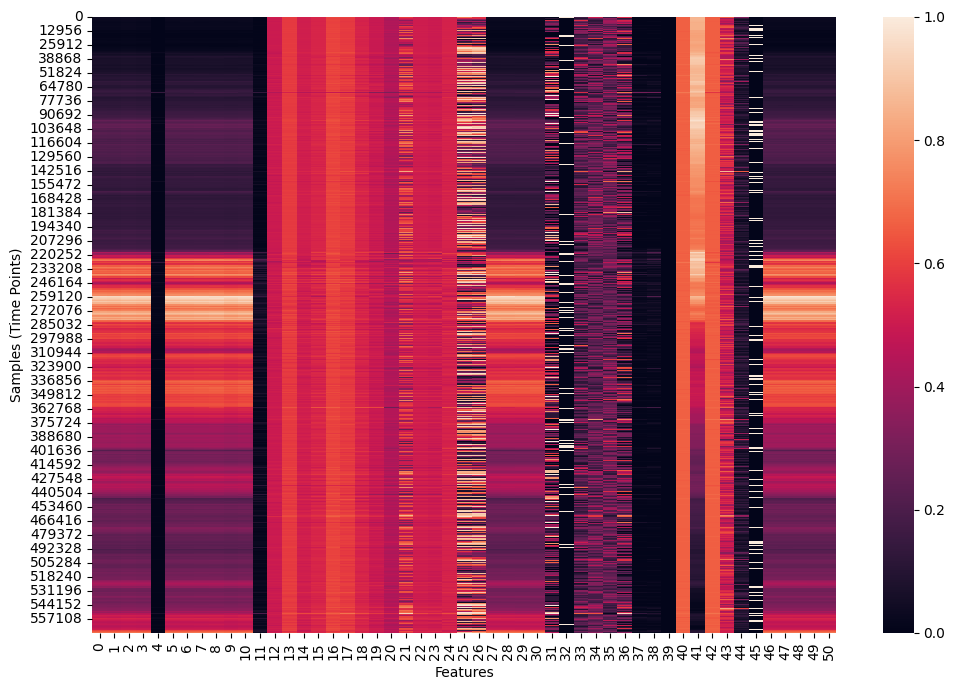

In [86]:
# Plotting NaN positions in X
plt.figure(figsize=(12, 8))
# plt.imshow(np.isnan(X), aspect='auto', cmap='viridis', interpolation='nearest')
sns.heatmap(X)
plt.xlabel("Features")
plt.ylabel("Samples (Time Points)")
plt.show()

In [ ]:
def time_series_split(data, labels, train_ratio=0.7, val_ratio=0.2):
    """
    时间序列分割，将数据按时间顺序划分为训练、验证和测试集。
    
    :param data: np.array, 特征矩阵
    :param labels: np.array, 标签
    :param train_ratio: float, 训练集比例
    :param val_ratio: float, 验证集比例
    :return: X_train, X_val, X_test, y_train, y_val, y_test
    """
    n = len(data)
    train_end = int(n * train_ratio)
    val_end = train_end + int(n * val_ratio)

    X_train = data[:train_end]
    y_train = labels[:train_end]
    X_val = data[train_end:val_end]
    y_val = labels[train_end:val_end]
    X_test = data[val_end:]
    y_test = labels[val_end:]

    return X_train, X_val, X_t
    est, y_train, y_val, y_test

In [88]:
# 数据集划分
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
X_train, X_val, X_test, y_train, y_val, y_test = time_series_split(X, y, train_ratio=0.8, val_ratio=0.15)

In [107]:
# 定义子模型
clf1 = CatBoostClassifier(iterations=500, depth=6, learning_rate=0.05, verbose=0)
clf2 = LGBMClassifier(n_estimators=500, learning_rate=0.05)

# 对于 LinearSVC，建议通过管道加入标准化
clf3 = make_pipeline(StandardScaler(), LinearSVC(max_iter=1000))

# 集成学习模型
model = VotingClassifier(estimators=[
    ('catboost', clf1), ('lightgbm', clf2), ('linearsvc', clf3)
], voting='hard')  # 'hard' 使用投票法，'soft' 使用概率加权

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

model_save_path = "voting_model.pkl"
joblib.dump(model, model_save_path)



[LightGBM] [Info] Number of positive: 225423, number of negative: 230593
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.033457 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12255
[LightGBM] [Info] Number of data points in the train set: 456016, number of used features: 51
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.494331 -> initscore=-0.022676
[LightGBM] [Info] Start training from score -0.022676


['voting_model.pkl']

训练集准确率: 0.76


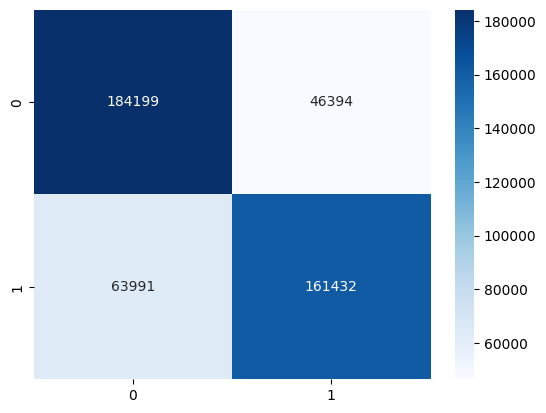

In [108]:

# 加载模型
model = joblib.load(model_save_path)

# 训练集预测
y_pred_train = model.predict(X_train)

# 计算准确率
accuracy = accuracy_score(y_train, y_pred_train)
print(f"训练集准确率: {accuracy:.2f}")

# 绘制混淆矩阵
cm = confusion_matrix(y_train, y_pred_train)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.show()

测试集准确率: 0.46


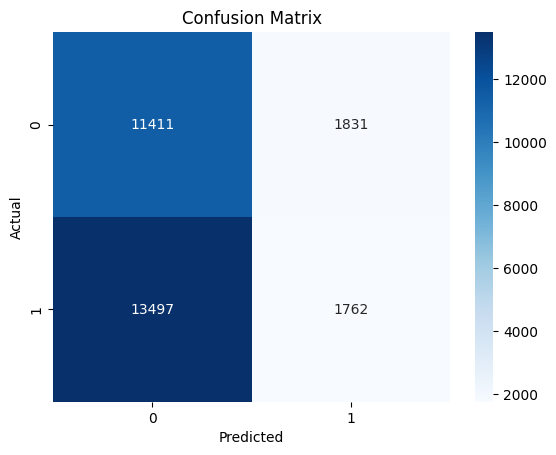

In [109]:
#测试集准确率比较

# 加载模型
model = joblib.load(model_save_path)
y_pred_binary = model.predict(X_test)
y_pred = (y_pred_binary > 0.5).astype(int)  # 将概率转化为类别标签，例如 [1, 0, 1]

# 计算准确率
accuracy = accuracy_score(y_test, y_pred)

print(f"测试集准确率: {accuracy:.2f}")


# 绘制混淆矩阵

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [110]:
def custom_threshold(y_pred, low_threshold=0.3, high_threshold=0.7):
    """
    根据自定义的阈值范围对预测结果进行分类。
    
    :param y_pred: np.array, XGBoost 的预测概率
    :param low_threshold: float, 下限阈值（低于此值为 0）
    :param high_threshold: float, 上限阈值（高于此值为 1）
    :return: np.array, 应用阈值后的分类结果
    """
    y_custom = np.where(y_pred < low_threshold, 0,  # 低于 low_threshold 分为 0
                        np.where(y_pred > high_threshold, 1, 0.5))  # 高于 high_threshold 分为 1，其余为 0.5
    return y_custom


def filter_ambiguous(y_test, y_pred, threshold=0.5):
    """
    去除 y_test 和 y_pred 中所有预测值为指定阈值的位置。
    
    :param y_test: np.array, 真实标签
    :param y_pred: np.array, 预测值
    :param threshold: float, 要过滤的阈值（默认 0.5）
    :return: tuple, 过滤后的 y_test 和 y_pred
    """
    mask = y_pred != threshold  # 创建掩码，过滤掉 y_pred 中等于阈值的元素
    y_test_filtered = y_test[mask]
    y_pred_filtered = y_pred[mask]
    return y_test_filtered, y_pred_filtered

去除后测试集准确率: 0.46


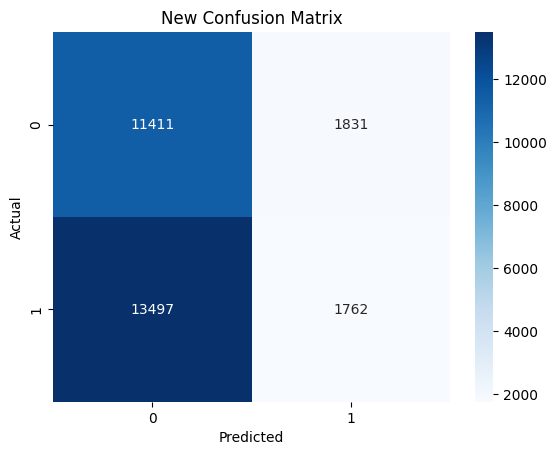

In [111]:
# 设置自定义阈值
low_threshold = 0.3
high_threshold = 0.7

# 应用自定义分类规则
y_pred2 = custom_threshold(y_pred_binary, low_threshold=low_threshold, high_threshold=high_threshold)
y_test_filtered, y_pred_filtered = filter_ambiguous(y_test, y_pred2, threshold=0.5)

accuracy = accuracy_score(y_test_filtered, y_pred_filtered)
print(f"去除后测试集准确率: {accuracy:.2f}")

# 绘制混淆矩阵
cm = confusion_matrix(y_test_filtered, y_pred_filtered)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("New Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [112]:
def prepare_test_data(file_path, window_size=100):
    """
    从测试数据中提取滑动窗口，并生成特征矩阵和对应标签。
    每个滑动窗口都调用 `load_and_prepare_data_real` 进行特征处理。
    
    :param file_path: 测试数据文件路径
    :param window_size: 滑动窗口大小
    :return: 测试特征矩阵 X_test 和标签 y_test
    """
    # 加载数据
    df = pd.read_pickle(file_path)

    # 滑动窗口处理
    X_test_windows = []
    y_test_windows = []
    for start_idx in  range(500 - window_size + 1):
    ##range(len(df) - window_size + 1):
        # 取当前滑动窗口数据
        window_df = df.iloc[start_idx:start_idx + window_size].copy()

        # 调用 `load_and_prepare_data_real` 对窗口数据进行特征处理
        X_window, y_window = load_and_prepare_data_real(window_df)

        # 添加窗口最后一个点的特征和标签
        X_test_windows.append(X_window[-1])  # 只取最后一行特征
        y_test_windows.append(y_window[-1])  # 只取最后一行标签

    # 转换为 NumPy 数组
    X_test = np.array(X_test_windows)
    y_test = np.array(y_test_windows)
    # print(f"生成测试集滑动窗口矩阵，形状为: {X_test.shape}, 标签形状为: {y_test.shape}")

    return X_test, y_test

In [113]:
# 文件路径
test_data_file_path = "LSTMTestData.pkl"

# 滑动窗口大小
window_size = 100
# 生成测试特征矩阵和标签
# X_test2, y_test2 = prepare_test_data(test_data_file_path, window_size=window_size)
X_test2, y_test2 = load_and_prepare_data(test_data_file_path,scaler_save_path)


缩放器已加载: scaler.pkl


测试集准确率: 0.50


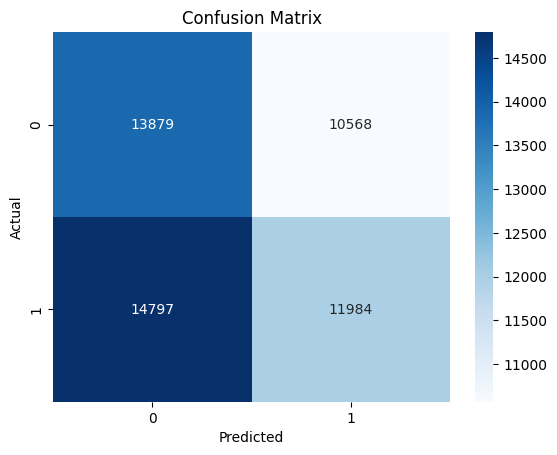

In [114]:

# 加载模型
model = joblib.load(model_save_path)
y_pred_binary = model.predict(X_test2)
y_pred2 = (y_pred_binary > 0.5).astype(int)  # 将概率转化为类别标签，例如 [1, 0, 1]

# 计算准确率
accuracy = accuracy_score(y_test2, y_pred2)
print(f"测试集准确率: {accuracy:.2f}")


# 绘制混淆矩阵
cm = confusion_matrix(y_test2, y_pred2)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [115]:
print(y_pred2.shape)

(51228,)


去除后测试集准确率: 0.50


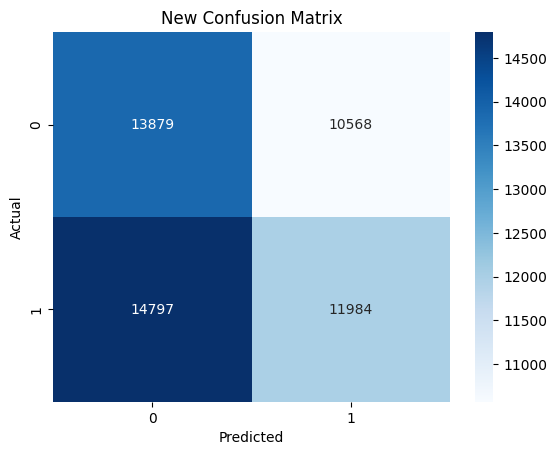

In [116]:

# 设置自定义阈值
low_threshold = 0.3
high_threshold = 0.7

# 应用自定义分类规则
y_pred3 = custom_threshold(y_pred_binary, low_threshold=low_threshold, high_threshold=high_threshold)

y_test_filtered, y_pred_filtered = filter_ambiguous(y_test2, y_pred3, threshold=0.5)

accuracy = accuracy_score(y_test_filtered, y_pred_filtered)
print(f"去除后测试集准确率: {accuracy:.2f}")

# 绘制混淆矩阵
cm = confusion_matrix(y_test_filtered, y_pred_filtered)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("New Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [117]:
print(y_pred_binary.shape)

(51228,)


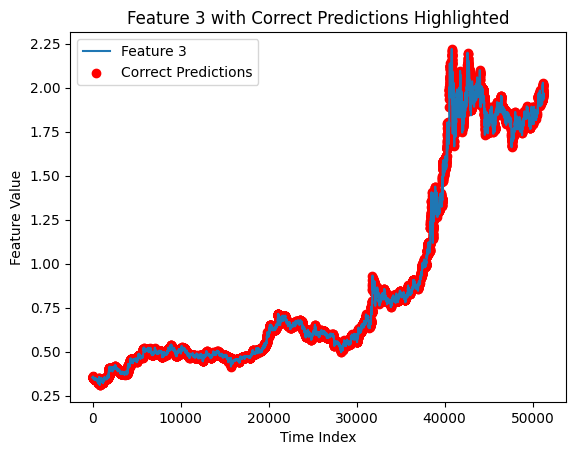

In [118]:
tt = range(len(X_test2))  # 时间序列
plt.plot(tt, X_test2[:, 3], label='Feature 3')  # 绘制特征 3 的曲线
correct_indices = np.where(y_test2 == y_pred3)[0]
plt.scatter(correct_indices, X_test2[correct_indices, 3], color='red', label='Correct Predictions')
plt.legend()
plt.title('Feature 3 with Correct Predictions Highlighted')
plt.xlabel('Time Index')
plt.ylabel('Feature Value')
plt.show()

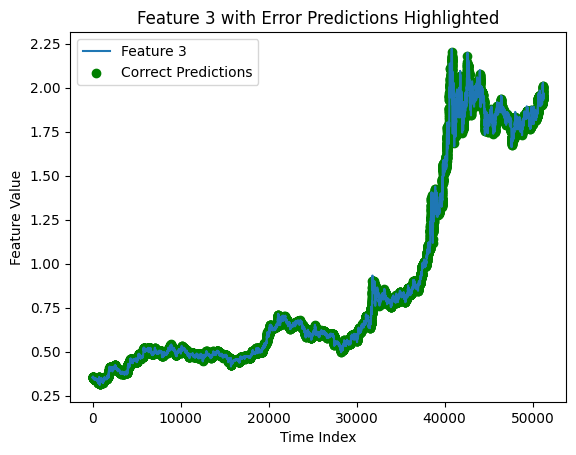

In [119]:
tt = range(len(X_test2))  # 时间序列
plt.plot(tt, X_test2[:, 3], label='Feature 3')  # 绘制特征 3 的曲线
correct_indices = np.where(y_test2 != y_pred3)[0]
plt.scatter(correct_indices, X_test2[correct_indices, 3], color='green', label='Correct Predictions')
plt.legend()
plt.title('Feature 3 with Error Predictions Highlighted')
plt.xlabel('Time Index')
plt.ylabel('Feature Value')
plt.show()